Bits TX: [1 1 0 0 1 1 0 0 0 0]
Bits RX: [1 1 0 0 1 1 0 0 0 0]
Erros: 0
BER: 0.0


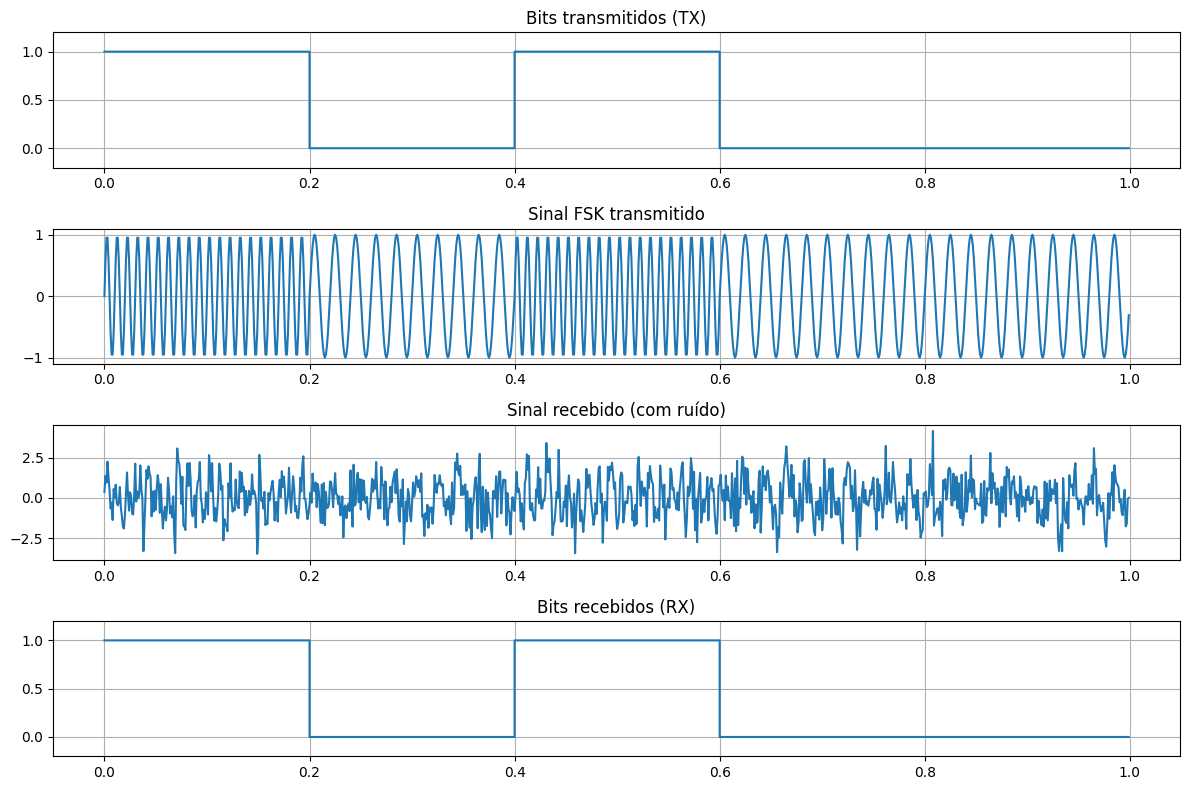

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# PARÂMETROS
num_bits = 10
amostras_por_bit = 100
fs = 1000
f0 = 50
f1 = 100
ruido = 1

# GERAÇÃO DOS BITS
bits = np.random.randint(0, 2, num_bits)
print("Bits TX:", bits)

t_bit = np.arange(amostras_por_bit) / fs

# MODULAÇÃO FSK
sinal = []

for bit in bits:
    if bit == 0:
        s = np.sin(2 * np.pi * f0 * t_bit)
    else:
        s = np.sin(2 * np.pi * f1 * t_bit)

    sinal.extend(s)

sinal = np.array(sinal)

# CANAL COM RUÍDO
sinal_rx = sinal + ruido * np.random.randn(len(sinal))

# DEMODULAÇÃO FSK
bits_recebidos = []

# sinais de referência
ref0 = np.sin(2 * np.pi * f0 * t_bit)
ref1 = np.sin(2 * np.pi * f1 * t_bit)

for i in range(num_bits):

    inicio = i * amostras_por_bit
    fim = inicio + amostras_por_bit
    trecho = sinal_rx[inicio:fim]

    # correlação
    c0 = np.sum(trecho * ref0)
    c1 = np.sum(trecho * ref1)

    # decisão
    if abs(c1) > abs(c0):
        bits_recebidos.append(1)
    else:
        bits_recebidos.append(0)

bits_recebidos = np.array(bits_recebidos)

print("Bits RX:", bits_recebidos)

# TAXA DE ERRO
erros = np.sum(bits != bits_recebidos)
print("Erros:", erros)
print("BER:", erros / num_bits)

# VISUALIZAÇÃO DOS BITS
bits_tx_plot = np.repeat(bits, amostras_por_bit)
bits_rx_plot = np.repeat(bits_recebidos, amostras_por_bit)

tempo_total = np.arange(len(sinal)) / fs

# GRÁFICOS
plt.figure(figsize=(12, 8))

# Bits transmitidos
plt.subplot(4, 1, 1)
plt.plot(tempo_total, bits_tx_plot, drawstyle='steps-post')
plt.title("Bits transmitidos (TX)")
plt.ylim(-0.2, 1.2)
plt.grid()

# Sinal transmitido
plt.subplot(4, 1, 2)
plt.plot(tempo_total, sinal)
plt.title("Sinal FSK transmitido")
plt.grid()

# Sinal recebido
plt.subplot(4, 1, 3)
plt.plot(tempo_total, sinal_rx)
plt.title("Sinal recebido (com ruído)")
plt.grid()

# Bits recebidos
plt.subplot(4, 1, 4)
plt.plot(tempo_total, bits_rx_plot, drawstyle='steps-post')
plt.title("Bits recebidos (RX)")
plt.ylim(-0.2, 1.2)
plt.grid()

plt.tight_layout()
plt.show()